In [ ]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
# dt = ds.Coco("/home/wanderer2414/coco2017/")
from dataset2 import YOLODataset, test
import config
from torch import tensor, arange, float as tfloat, stack
import matplotlib.pyplot as plt
import matplotlib.patches as pat
dt = ds.Coco("/home/wanderer2414/PASCAL_VOC")

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/home/wanderer2414/MyRCNN/config.py:78: UserWarning: Argument(s) 'mode, cval' are not valid for transform Affine
  A.Affine(shear=15, p=0.5, mode=cv2.BORDER_CONSTANT, cval=0), # Updated from deprecated IAAAffin

In [2]:
# import MyRCNN
# import torch
# dev = "cpu"
# model = MyRCNN.Model(device=torch.device(dev))
# model.model.load_state_dict(torch.load("bbx.pth", map_location=dev))
def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

# print(count_parameters(model.model.color))

In [3]:
import MyRCNN
import torch
device = "cuda"
model = MyRCNN.Model(dt,device=torch.device(device))
print(count_parameters(model.model))
# for module in model.model.color.prepare.modules():
#     print(module)
model.train()

893
Load model!
Load model!


In [4]:
model.Evaluate()

[00:08:21] AP: 0.0759466215968132         ██████████████████████████████████████████████████████████ 4951     /     4951


tensor(0.0759)

In [5]:
from torch import Tensor,cdist
def nms(boxes: Tensor, threshold : float) -> Tensor:
    cx = (boxes[:, 0] + boxes[:,2])/2
    cy = (boxes[:, 1] + boxes[:,3])/2
    N = boxes.shape[0]
    c = stack([cx, cy], dim=-1)
    a = c.view(1, N, 2).expand(N, N, 2)
    b = c.view(N, 1, 2).expand(N, N, 2)
    x = arange(N).view(1, N).expand(N, N)
    y = arange(N).view(N, 1).expand(N, N)
    indices = y > x
    d = (a - b).square().sum(dim=-1)
    d = d*indices
    print(d.shape)
    return boxes
    


In [6]:

from torch import stack
import torch
from torch import Tensor
def nms(boxes: Tensor)->Tensor:
    N = boxes.shape[0]
    rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
    boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
    boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
    x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
    x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
    w = x2 - x1
    del x1, x2
    y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
    y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
    h = y2-y1
    del y2, y1
    s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
    s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
    intersect = w*h
    IoU = intersect/(s - intersect)
    IoU = IoU * (rows>cols)
    cond = IoU > 0.9
    indices = (cond.any(dim=1).logical_not())
    
    return boxes[indices]

def mode_pool2d(x, kernel_size=3, stride=1, padding=0) -> Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)
import gc
gc.collect()

0

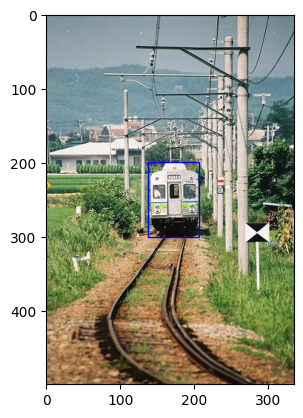

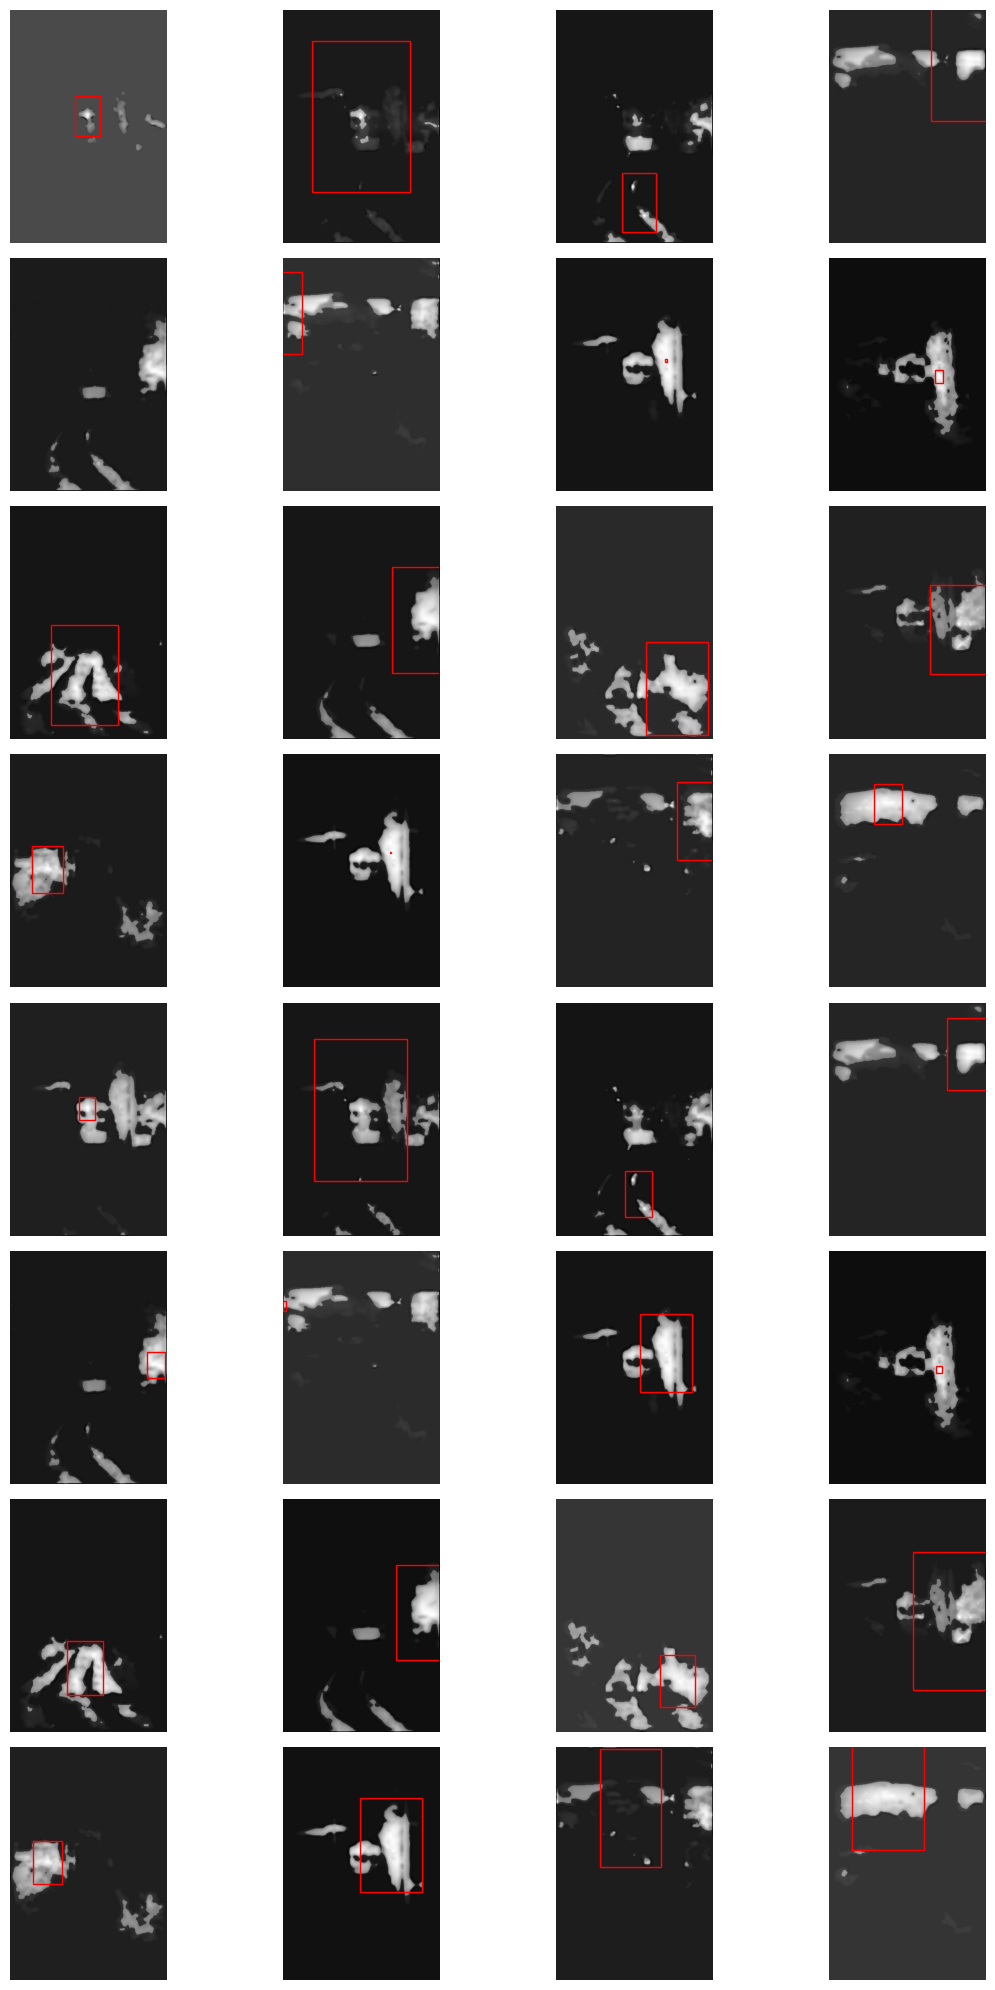

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from dataset import TensorToImg, ImgToTensor
i = 0
x = dt.getTestTensor(i).to(device=torch.device(device))
label = dt.getTestLabel(i)

mask, color, score, bbx = model.model(x)
x1, y1, x2, y2, cls = label[0]
rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='blue')
plt.subplot().add_patch(rect)
plt.imshow(TensorToImg(x.detach().cpu()))

boxes = model.inference(x)

N = color.shape[1]
boxes = boxes.view(N, -1, 6).max(dim=1).values
fig, axes = plt.subplots(N//4, 4, figsize=(12, 20))
# cls_range = arange(20).view(20, 1, 1).expand(20, N, 1)
# print(cls_range.shape)
for i, ax in enumerate(axes.flat):
    x = color[:, i:i+1, :, :]
    x = x.repeat(1, 3, 1, 1)
    x = x-x.min()
    x = x/x.max()
    cls, score, x1, y1, x2, y2 = boxes[i].detach().cpu().numpy()
    rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
    ax.add_patch(rect)
    
    ax.imshow(TensorToImg(x.detach().cpu()))
    ax.axis('off')
plt.tight_layout()
plt.show()
